

**Sections**
1. Overall test performance — F2, precision, recall, Brier score, bootstrap 95% CIs
2. Per-park breakdown — F2 heatmaps across six Nigerian national parks
3. Calibration diagnostics — reliability diagrams for all models
4. Lead-time analysis — mean days of advance warning per threat

## Metrics Reference

All metrics computed on the held-out test set (Jan 2024 onward) at threshold 0.50 unless noted.

| Metric | What it measures | Range | Better when |
|---|---|---|---|
| **F2** | Weighted harmonic mean of precision and recall, recall weighted 2× — **primary metric** | 0–1 | Higher |
| **Precision** | Of all positive predictions, fraction correct | 0–1 | Higher |
| **Recall** | Of all actual positives, fraction detected | 0–1 | Higher |
| **Brier** | Mean squared error between predicted probability and true label | 0–1 | Lower |
| **ROC-AUC** | Probability model ranks a positive above a negative; threshold-independent | 0–1 | Higher |
| **95% CI** | Bootstrap CI for F2 (1,000 non-parametric resamples) | — | Narrow |
| **Persist F2** | F2 of persistence baseline: predict today's label as tomorrow's | 0–1 | — |
| **Lead time** | Mean days advance warning before event onset, at P ≥ 0.70 | days | Higher |

**Why F2 over F1?** Missing a real threat (false negative) costs more than a false alarm.
F2 penalises missed detections twice as heavily as F1.

In [19]:
import json
import pickle
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
from sklearn.calibration import calibration_curve

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT / "src" / "models"))

from model_utils import apply_platt, load_splits, prep_arrays
from evaluate import THREAT_LABELS
from seq_utils import build_sequence_splits
from supervised.train_lstm import ThreatLSTM, predict_proba as lstm_predict
from supervised.train_transformer import ThreatTransformer, predict_proba as tf_predict

RESULTS = ROOT / "results"
MODELS  = RESULTS / "models"
(RESULTS / "plots").mkdir(parents=True, exist_ok=True)

THREAT_SHORT = {
    "fire_within_30d":       "Fire",
    "drought_within_30d":    "Drought",
    "vegetation_within_30d": "Vegetation",
}
PARK_LABELS = {
    "chad_basin":    "Chad Basin",
    "cross_river":   "Cross River",
    "gashaka_gumti": "Gashaka-Gumti",
    "kainji_lake":   "Kainji Lake",
    "old_oyo":       "Old Oyo",
    "yankari":       "Yankari",
}
MODEL_COLORS = {
    "RF":          "#2196F3",
    "XGBoost":     "#FF5722",
    "LSTM":        "#4CAF50",
    "Transformer": "#9C27B0",
}
MODELS_ORDER = ["RF", "XGBoost", "LSTM", "Transformer"]

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
print("Setup complete. ROOT:", ROOT)

Setup complete. ROOT: C:\Users\fadhl\Desktop\Capstone\ConserveAI


In [20]:
result_files = {
    "RF":          "rf_supervised_results.json",
    "XGBoost":     "xgb_supervised_results.json",
    "LSTM":        "lstm_supervised_results.json",
    "Transformer": "transformer_supervised_results.json",
}
res = {}
for name, fname in result_files.items():
    with open(RESULTS / fname) as f:
        res[name] = json.load(f)
    print(f"{name:12s} test mean-F2: {res[name]['test_mean_f2']:.4f}")

RF           test mean-F2: 0.8565
XGBoost      test mean-F2: 0.8267
LSTM         test mean-F2: 0.7768
Transformer  test mean-F2: 0.6886


## 1. Overall Test Performance

F2 (beta=2) is the primary metric. Bootstrap 95% CIs use 1,000 non-parametric resamples.
Neural models (LSTM, Transformer) use early stopping on validation loss; tree models use grid search.

In [21]:
rows = []
for model_name in MODELS_ORDER:
    for label in THREAT_LABELS:
        m  = res[model_name]["test_metrics"][label]
        ci = m["bootstrap_f2"]
        rows.append({
            "Model":          model_name,
            "Threat":         THREAT_SHORT[label],
            "F2":             round(m["f2"], 4),
            "95% CI":         f"[{ci['ci_lower']:.4f}, {ci['ci_upper']:.4f}]",
            "Precision":      round(m["precision"], 4),
            "Recall":         round(m["recall"], 4),
            "Brier":          round(m["brier"], 4),
            "ROC-AUC":        round(m["roc_auc"], 4),
            "Persist F2":     round(m["persistence_f2"], 4),
            "Beats Baseline": "Yes" if m["beats_baseline"] else "No",
        })

df_compare = pd.DataFrame(rows).set_index(["Model", "Threat"])
df_compare

F2            95% CI  Precision  Recall   Brier  \
Model       Threat                                                            
RF          Fire        0.9436  [0.9371, 0.9504]     0.8799  0.9610  0.0727   
            Drought     0.8818  [0.8636, 0.8990]     0.7264  0.9317  0.0602   
            Vegetation  0.7441  [0.7278, 0.7602]     0.6172  0.7844  0.2326   
XGBoost     Fire        0.9355  [0.9277, 0.9434]     0.8799  0.9505  0.0774   
            Drought     0.8415  [0.8183, 0.8618]     0.7028  0.8851  0.0613   
            Vegetation  0.7030  [0.6842, 0.7218]     0.6645  0.7134  0.2295   
LSTM        Fire        0.9384  [0.9314, 0.9453]     0.8335  0.9688  0.0983   
            Drought     0.7464  [0.7186, 0.7703]     0.5579  0.8152  0.1142   
            Vegetation  0.6458  [0.6257, 0.6657]     0.5138  0.6901  0.2446   
Transformer Fire        0.9407  [0.9340, 0.9474]     0.8416  0.9693  0.0974   
            Drought     0.5961  [0.5634, 0.6284]     0.5405  0.6118  0.1079   
            Vegetation  0.5291  [0.5080, 0.5509]     0.5190  0.5317  0.2455   

                        ROC-AUC  Persist F2 Beats Baseline  
Model       Threat                                          
RF          Fire         0.9781      0.7798            Yes  
            Drought      0.9686      0.3991            Yes  
            Vegetation   0.7773      0.4796            Yes  
XGBoost     Fire         0.9764      0.7798            Yes  
            Drought      0.9620      0.3991            Yes  
            Vegetation   0.7923      0.4796            Yes  
LSTM        Fire         0.9755      0.7798            Yes  
            Drought      0.9161      0.3991            Yes  
            Vegetation   0.6641      0.4796            Yes  
Transformer Fire         0.9674      0.7798            Yes  
            Drought      0.8679      0.3991            Yes  
            Vegetation   0.6700      0.4796            Yes

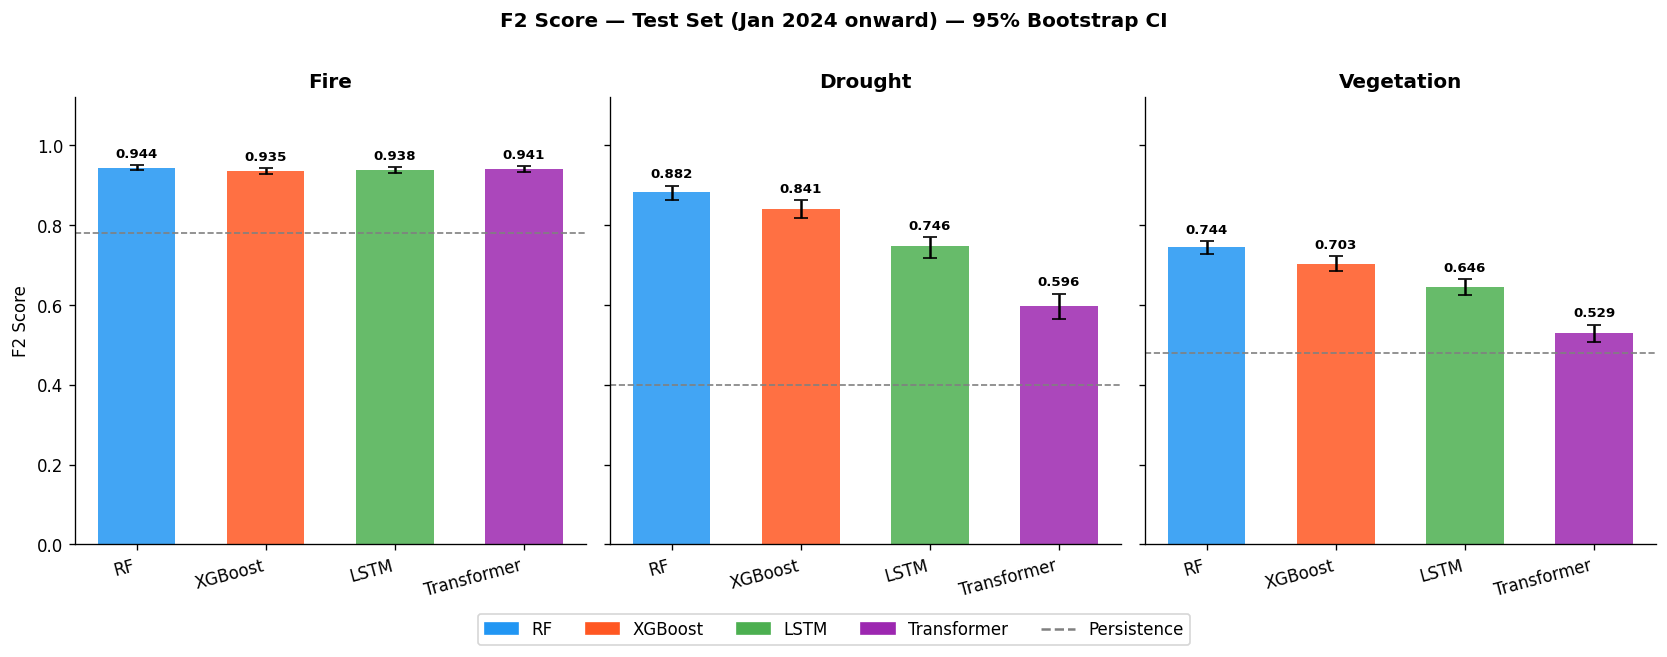

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

for ax, label in zip(axes, THREAT_LABELS):
    x_pos = np.arange(len(MODELS_ORDER))
    for j, model_name in enumerate(MODELS_ORDER):
        m  = res[model_name]["test_metrics"][label]
        ci = m["bootstrap_f2"]
        f2 = m["f2"]
        lo = f2 - ci["ci_lower"]
        hi = ci["ci_upper"] - f2
        ax.bar(j, f2, color=MODEL_COLORS[model_name], alpha=0.85, width=0.6)
        ax.errorbar(j, f2, yerr=[[lo], [hi]], fmt="none",
                    color="black", capsize=4, linewidth=1.5)
        ax.text(j, ci["ci_upper"] + 0.012, f"{f2:.3f}",
                ha="center", va="bottom", fontsize=8, fontweight="bold")

    persist = res["RF"]["test_metrics"][label]["persistence_f2"]
    ax.axhline(persist, color="gray", linestyle="--", linewidth=1)
    ax.set_title(THREAT_SHORT[label], fontweight="bold")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(MODELS_ORDER, rotation=15, ha="right")
    ax.set_ylim(0, 1.12)
    if ax is axes[0]:
        ax.set_ylabel("F2 Score")

handles = [
    mpatches.Patch(color=MODEL_COLORS[m], label=m) for m in MODELS_ORDER
] + [plt.Line2D([0],[0], color="gray", linestyle="--", label="Persistence")]
fig.legend(handles=handles, loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.06))
fig.suptitle("F2 Score — Test Set (Jan 2024 onward) — 95% Bootstrap CI",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(RESULTS / "plots" / "f2_all_models.png", bbox_inches="tight")
plt.show()

## 2. Per-Park Breakdown

F2 scores per park and threat for all four models. Green = high (> 0.80), red = low (< 0.40).

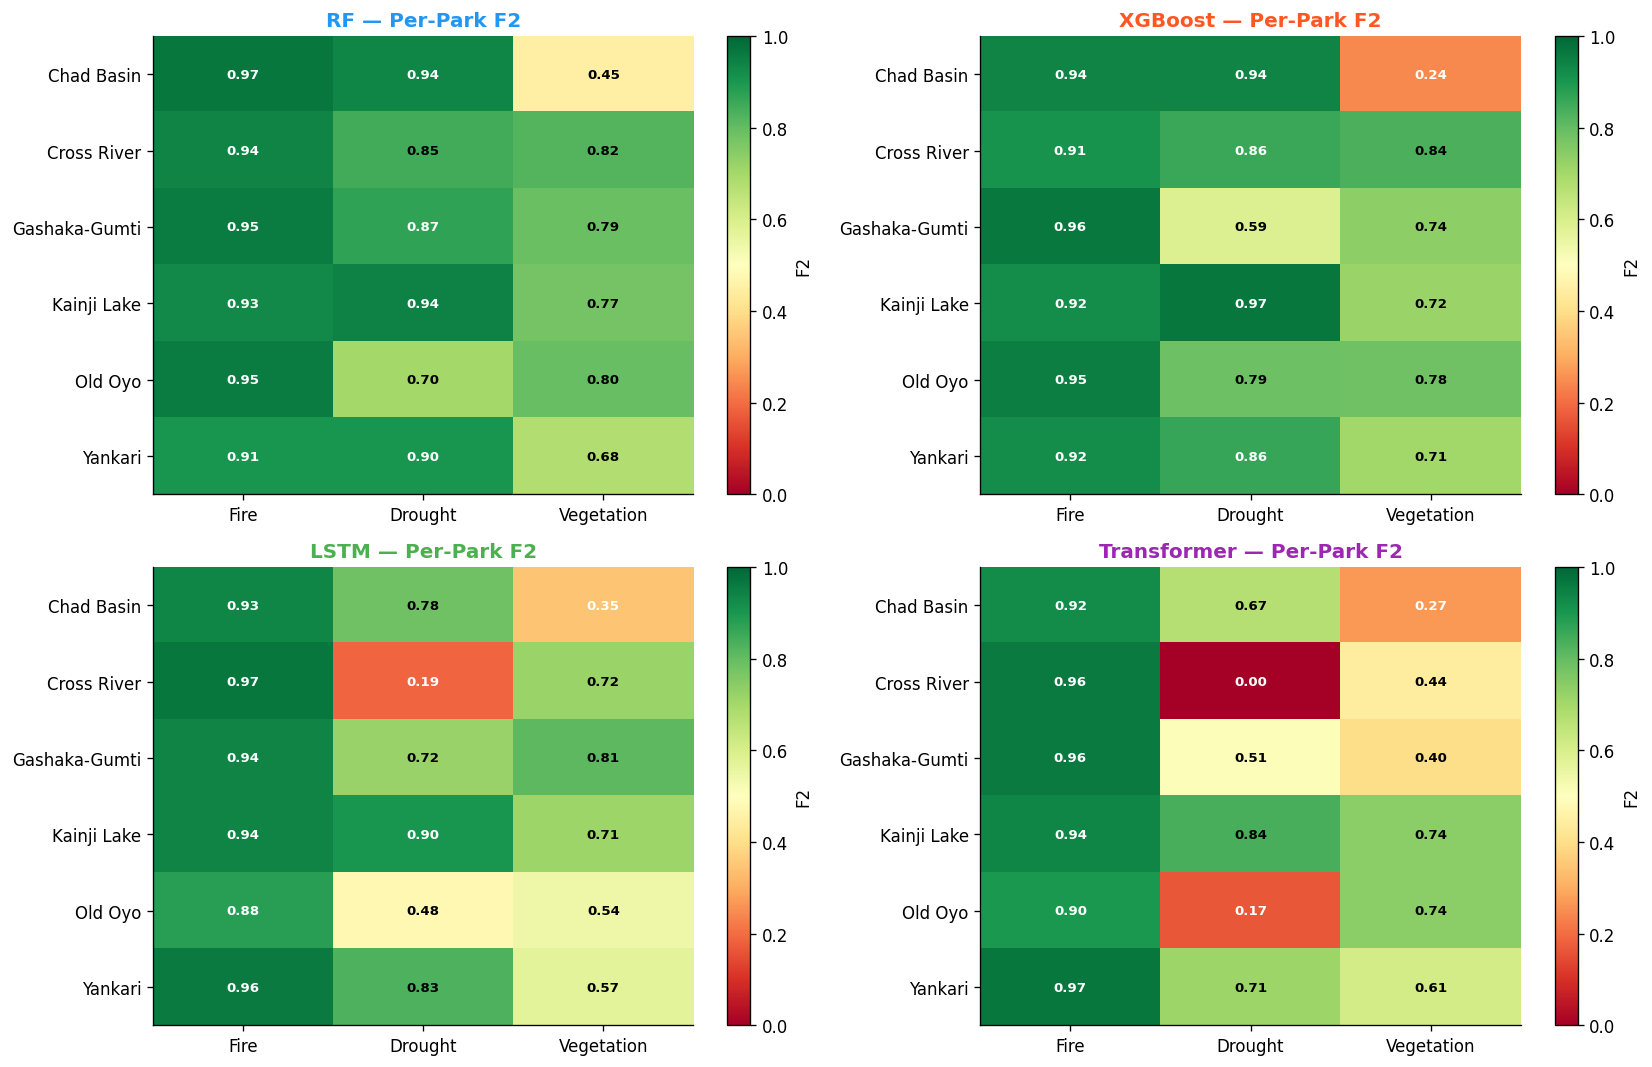

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes_flat = axes.flatten()

for ax, model_name in zip(axes_flat, MODELS_ORDER):
    parks = list(res[model_name]["per_park_test"].keys())
    data  = np.array([
        [res[model_name]["per_park_test"][p][l]["f2"] for l in THREAT_LABELS]
        for p in parks
    ])
    park_display  = [PARK_LABELS.get(p, p) for p in parks]
    threat_display = [THREAT_SHORT[l] for l in THREAT_LABELS]

    im = ax.imshow(data, vmin=0, vmax=1, cmap="RdYlGn", aspect="auto")
    ax.set_xticks(range(3))
    ax.set_xticklabels(threat_display)
    ax.set_yticks(range(len(parks)))
    ax.set_yticklabels(park_display)
    ax.set_title(f"{model_name} — Per-Park F2", fontweight="bold",
                 color=MODEL_COLORS[model_name])
    for i in range(len(parks)):
        for j in range(3):
            v = data[i, j]
            tc = "white" if v < 0.35 or v > 0.85 else "black"
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    color=tc, fontsize=8, fontweight="bold")
    plt.colorbar(im, ax=ax, label="F2")

plt.tight_layout()
plt.savefig(RESULTS / "plots" / "per_park_f2_all_models.png", bbox_inches="tight")
plt.show()

In [24]:
park_rows = []
for model_name in MODELS_ORDER:
    for park, pm in res[model_name]["per_park_test"].items():
        row = {"Model": model_name, "Park": PARK_LABELS.get(park, park)}
        for label in THREAT_LABELS:
            row[THREAT_SHORT[label]] = round(pm[label]["f2"], 3)
        park_rows.append(row)

df_park = pd.DataFrame(park_rows).set_index(["Model", "Park"])
df_park

Fire  Drought  Vegetation
Model       Park                                     
RF          Chad Basin     0.967    0.936       0.449
            Cross River    0.938    0.846       0.822
            Gashaka-Gumti  0.954    0.869       0.793
            Kainji Lake    0.928    0.942       0.775
            Old Oyo        0.953    0.703       0.796
            Yankari        0.905    0.903       0.679
XGBoost     Chad Basin     0.941    0.939       0.245
            Cross River    0.907    0.859       0.835
            Gashaka-Gumti  0.964    0.589       0.735
            Kainji Lake    0.920    0.966       0.718
            Old Oyo        0.952    0.789       0.781
            Yankari        0.922    0.861       0.706
LSTM        Chad Basin     0.934    0.784       0.347
            Cross River    0.965    0.188       0.717
            Gashaka-Gumti  0.938    0.721       0.809
            Kainji Lake    0.941    0.903       0.713
            Old Oyo        0.879    0.477       0.543
            Yankari        0.961    0.831       0.572
Transformer Chad Basin     0.925    0.668       0.266
            Cross River    0.960    0.000       0.438
            Gashaka-Gumti  0.960    0.509       0.397
            Kainji Lake    0.936    0.837       0.739
            Old Oyo        0.896    0.168       0.738
            Yankari        0.966    0.713       0.612

## 3. Calibration Diagnostics

Reliability diagrams — predicted probability vs. observed event frequency.
Points on the diagonal = perfect calibration.
All models use Platt scaling on the validation set; where the Platt coefficient was
negative (vegetation in every model), temperature scaling was applied as a fallback.
Temperature scaling can only stretch or compress probabilities — it cannot invert the
signal — producing trustworthy vegetation probability estimates on the dashboard.

In [25]:
device = torch.device("cpu")

# Tree models
_, _, test_df = load_splits()
with open(MODELS / "rf_supervised"  / "model.pkl", "rb") as f: rf_b  = pickle.load(f)
with open(MODELS / "xgb_supervised" / "model.pkl", "rb") as f: xgb_b = pickle.load(f)

X_test_flat, Y_test_flat, _ = prep_arrays(test_df, rf_b["imputer"])
rf_probs  = apply_platt(np.column_stack([p[:,1] for p in rf_b["model"].predict_proba(X_test_flat)]),  rf_b["calibrators"])
xgb_probs = apply_platt(np.column_stack([m.predict_proba(X_test_flat)[:,1] for m in xgb_b["models"]]), xgb_b["calibrators"])

# Neural models
(*_, X_test_seq, Y_test_seq, _parks) = build_sequence_splits()

with open(MODELS / "lstm_supervised" / "model.pkl", "rb") as f: lstm_b = pickle.load(f)
lstm_model = ThreatLSTM(**lstm_b["model_config"])
lstm_model.load_state_dict(lstm_b["model_state"])
lstm_probs = apply_platt(lstm_predict(lstm_model, X_test_seq, device), lstm_b["calibrators"])

with open(MODELS / "transformer_supervised" / "model.pkl", "rb") as f: tf_b = pickle.load(f)
tf_model = ThreatTransformer(**tf_b["model_config"])
tf_model.load_state_dict(tf_b["model_state"])
tf_probs = apply_platt(tf_predict(tf_model, X_test_seq, device), tf_b["calibrators"])

all_probs = {"RF": rf_probs, "XGBoost": xgb_probs, "LSTM": lstm_probs, "Transformer": tf_probs}
print("Probabilities loaded for all four models.")

Sequence splits built:
  train  X=(6414, 30, 20)  Y=(6414, 3)
  val    X=(970, 30, 20)  Y=(970, 3)
  test   X=(3992, 30, 20)  Y=(3992, 3)
Probabilities loaded for all four models.


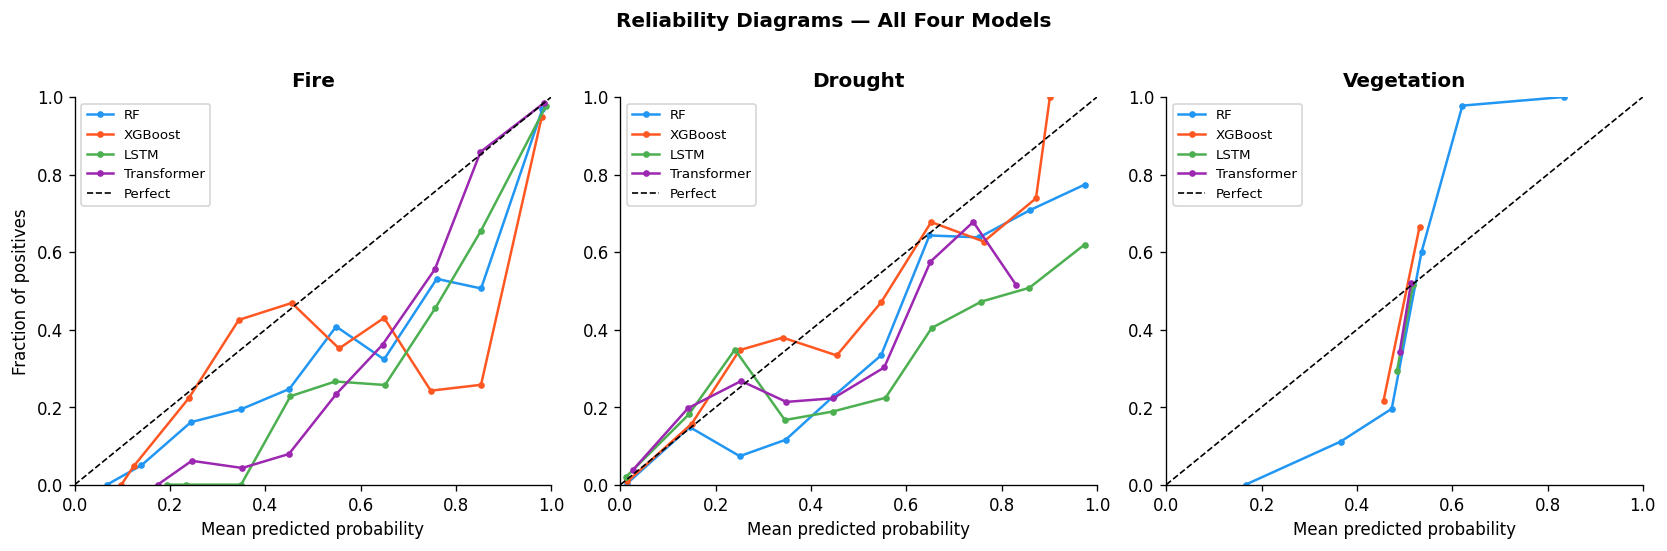

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, (i, label) in zip(axes, enumerate(THREAT_LABELS)):
    y_true_raw = Y_test_flat[:, i].astype(float)
    valid  = ~np.isnan(y_true_raw)
    y_true = y_true_raw[valid].astype(int)

    for model_name, probs in all_probs.items():
        yp = probs[valid, i]
        frac, mean_pred = calibration_curve(y_true, yp, n_bins=10, strategy="uniform")
        ax.plot(mean_pred, frac, marker="o", markersize=3,
                color=MODEL_COLORS[model_name], label=model_name, linewidth=1.5)

    ax.plot([0,1],[0,1], "k--", linewidth=1, label="Perfect")
    ax.set_title(THREAT_SHORT[label], fontweight="bold")
    ax.set_xlabel("Mean predicted probability")
    if i == 0: ax.set_ylabel("Fraction of positives")
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.legend(fontsize=8)

fig.suptitle("Reliability Diagrams — All Four Models", fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(RESULTS / "plots" / "reliability_all_models.png", bbox_inches="tight")
plt.show()

## 4. Lead-Time Analysis

Mean days before each positive-event onset that the model first crosses P ≥ 0.70.

Threat       Drought  Fire  Vegetation
Model                                 
LSTM            1.85  2.96         0.0
RF              3.06  3.65         0.1
Transformer     1.93  2.96         0.0
XGBoost         3.70  3.63         0.0


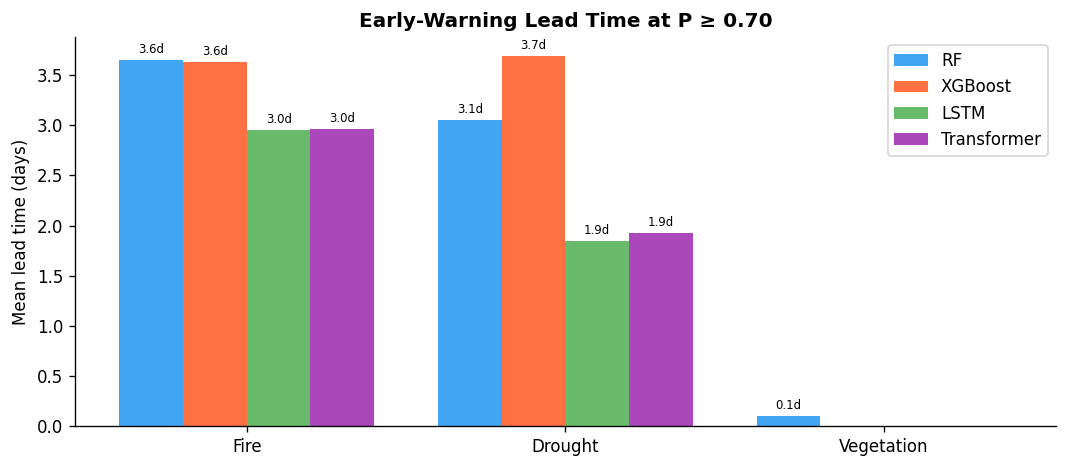

In [27]:
lt_rows = []
for model_name in MODELS_ORDER:
    for label in THREAT_LABELS:
        lt = res[model_name]["test_metrics"][label]["lead_time_days"]
        lt_rows.append({"Model": model_name, "Threat": THREAT_SHORT[label],
                        "Lead Time (days)": round(lt, 2)})

df_lt = pd.DataFrame(lt_rows)
print(df_lt.pivot(index="Model", columns="Threat", values="Lead Time (days)").to_string())

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(3)
w = 0.20
offsets = [-1.5, -0.5, 0.5, 1.5]

for j, model_name in enumerate(MODELS_ORDER):
    vals = [res[model_name]["test_metrics"][l]["lead_time_days"] for l in THREAT_LABELS]
    bars = ax.bar(x + offsets[j]*w, vals, w,
                  color=MODEL_COLORS[model_name], alpha=0.85, label=model_name)
    for bar, v in zip(bars, vals):
        if v > 0.1:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.04,
                    f"{v:.1f}d", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels([THREAT_SHORT[l] for l in THREAT_LABELS])
ax.set_ylabel("Mean lead time (days)")
ax.set_title("Early-Warning Lead Time at P \u2265 0.70", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / "plots" / "lead_time_all_models.png", bbox_inches="tight")
plt.show()

## Summary

| Model | Mean F2 | Fire F2 | Drought F2 | Vegetation F2 |
|---|---|---|---|---|
| Random Forest     | **0.8565** | 0.9436 | **0.8818** | **0.7441** |
| XGBoost           | 0.8267 | 0.9355 | 0.8415 | 0.7030 |
| LSTM              | 0.7768 | 0.9384 | 0.7464 | 0.6458 |
| Transformer       | 0.6886 | **0.9407** | 0.5961 | 0.5291 |
| Persistence (RF)  | — | 0.7798 | 0.3991 | 0.4796 |

All four models beat the persistence baseline on all three threats.
Random Forest achieves the highest mean F2 and is the primary supervised baseline.

**Key findings**
- **Fire** is well-handled by all architectures (F2 > 0.93) — the temporal fire-history
  features provide a strong signal that all models exploit.
- **Tree models dominate drought and vegetation** — engineered rain-deficit and NDVI
  features carry the prediction without needing sequence memory.
- **Neural models overfit on this dataset** — LSTM stopped at epoch 72, Transformer at
  epoch 18; both show train loss well below val loss. The 6,414 training sequences are
  insufficient for the attention mechanism to learn useful patterns.
- **Vegetation Platt scaler inverts in every model** — consistent finding across all
  four architectures; root cause is the rainy-season (Jul–Dec 2023) validation window
  producing an anti-correlated calibration signal for vegetation. Temperature scaling
  was applied as a fallback (T = 10.0 for all models); unlike Platt scaling, temperature
  scaling can only stretch or compress probabilities and cannot invert the signal.
- **Random Forest is selected as the supervised baseline for the semi-supervised stage
  (Week 7)** based on highest mean F2 and most consistent per-park performance.

## 5. Accuracy, Confusion Matrices & Classification Reports

Accuracy and per-class metrics at threshold 0.50.
Confusion matrix layout: rows = true label, columns = predicted label.
Class 1 = event present within 30 days; Class 0 = no event.

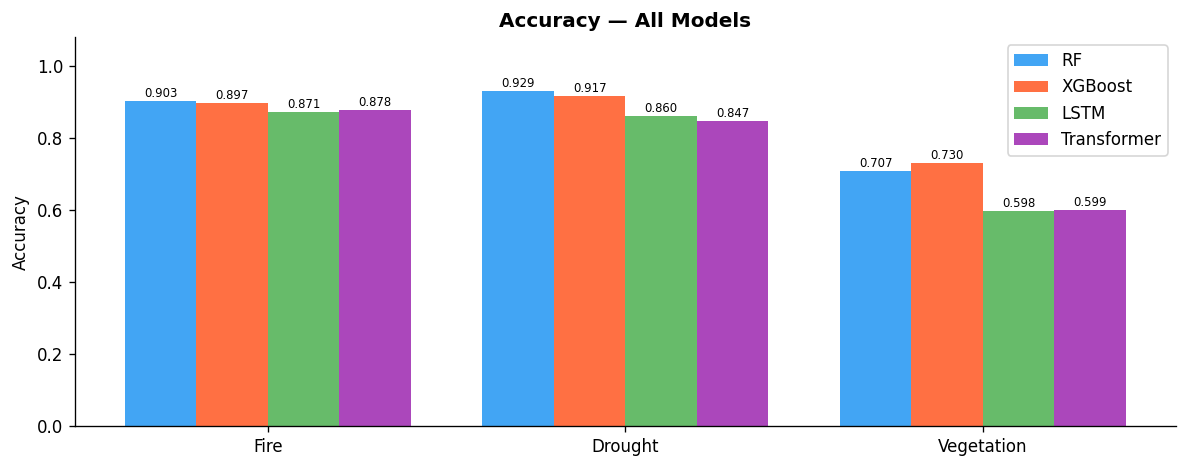

In [28]:
fig, ax = plt.subplots(figsize=(10, 4))
x       = np.arange(3)
w       = 0.20
offsets = [-1.5, -0.5, 0.5, 1.5]

for j, model_name in enumerate(MODELS_ORDER):
    accs = [res[model_name]["test_metrics"][l]["accuracy"] for l in THREAT_LABELS]
    bars = ax.bar(x + offsets[j] * w, accs, w,
                  color=MODEL_COLORS[model_name], alpha=0.85, label=model_name)
    for bar, v in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f"{v:.3f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels([THREAT_SHORT[l] for l in THREAT_LABELS])
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.08)
ax.set_title("Accuracy — All Models", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / "plots" / "accuracy_all_models.png", bbox_inches="tight")
plt.show()

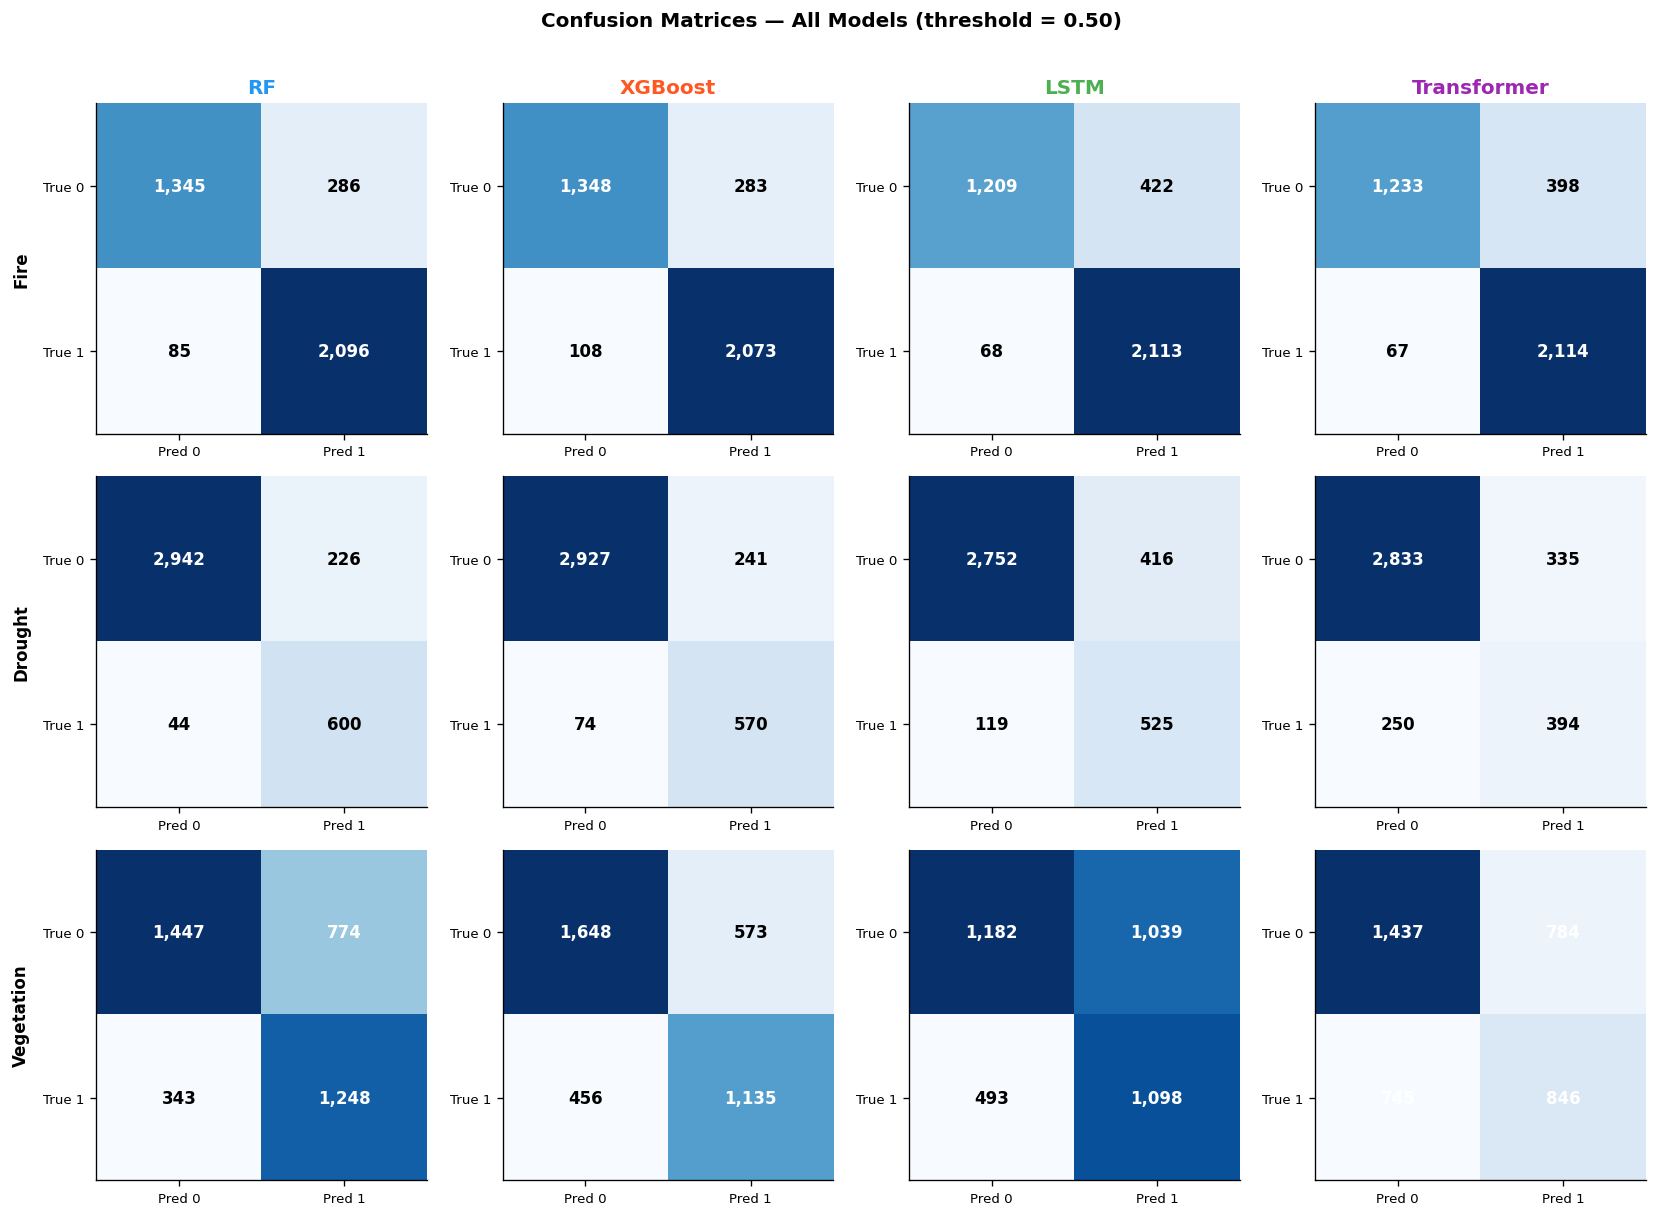

In [29]:
fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for row, label in enumerate(THREAT_LABELS):
    for col, model_name in enumerate(MODELS_ORDER):
        ax   = axes[row, col]
        cm_d = res[model_name]["test_metrics"][label]["confusion_matrix"]
        cm   = np.array([[cm_d["tn"], cm_d["fp"]], [cm_d["fn"], cm_d["tp"]]])

        ax.imshow(cm, cmap="Blues", interpolation="nearest")
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(["Pred 0", "Pred 1"], fontsize=8)
        ax.set_yticklabels(["True 0", "True 1"], fontsize=8)

        thresh = cm.max() / 2
        for i in range(2):
            for j in range(2):
                ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                        fontsize=10, fontweight="bold",
                        color="white" if cm[i, j] > thresh else "black")

        if row == 0:
            ax.set_title(model_name, fontweight="bold", color=MODEL_COLORS[model_name])
        if col == 0:
            ax.set_ylabel(THREAT_SHORT[label], fontweight="bold", labelpad=8)

fig.suptitle("Confusion Matrices — All Models (threshold = 0.50)", fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(RESULTS / "plots" / "confusion_matrices_all_models.png", bbox_inches="tight")
plt.show()

In [30]:
cr_rows = []
for model_name in MODELS_ORDER:
    for label in THREAT_LABELS:
        m  = res[model_name]["test_metrics"][label]
        cr = m["classification_report"]
        cr_rows.append({
            "Model":      model_name,
            "Threat":     THREAT_SHORT[label],
            "Accuracy":   round(m["accuracy"], 4),
            "Prec (0)":   round(cr["0"]["precision"], 4),
            "Recall (0)": round(cr["0"]["recall"], 4),
            "F1 (0)":     round(cr["0"]["f1-score"], 4),
            "Prec (1)":   round(cr["1"]["precision"], 4),
            "Recall (1)": round(cr["1"]["recall"], 4),
            "F1 (1)":     round(cr["1"]["f1-score"], 4),
            "Macro F1":   round(cr["macro avg"]["f1-score"], 4),
            "Wtd F1":     round(cr["weighted avg"]["f1-score"], 4),
        })

df_cr = pd.DataFrame(cr_rows).set_index(["Model", "Threat"])
df_cr

Accuracy  Prec (0)  Recall (0)  F1 (0)  Prec (1)  \
Model       Threat                                                         
RF          Fire          0.9027    0.9406      0.8246  0.8788    0.8799   
            Drought       0.9292    0.9853      0.9287  0.9561    0.7264   
            Vegetation    0.7070    0.8084      0.6515  0.7215    0.6172   
XGBoost     Fire          0.8974    0.9258      0.8265  0.8733    0.8799   
            Drought       0.9174    0.9753      0.9239  0.9489    0.7028   
            Vegetation    0.7301    0.7833      0.7420  0.7621    0.6645   
LSTM        Fire          0.8715    0.9468      0.7413  0.8315    0.8335   
            Drought       0.8597    0.9586      0.8687  0.9114    0.5579   
            Vegetation    0.5981    0.7057      0.5322  0.6068    0.5138   
Transformer Fire          0.8780    0.9485      0.7560  0.8414    0.8416   
            Drought       0.8465    0.9189      0.8943  0.9064    0.5405   
            Vegetation    0.5989    0.6586      0.6470  0.6527    0.5190   

                        Recall (1)  F1 (1)  Macro F1  Wtd F1  
Model       Threat                                            
RF          Fire            0.9610  0.9187    0.8987  0.9016  
            Drought         0.9317  0.8163    0.8862  0.9325  
            Vegetation      0.7844  0.6908    0.7062  0.7087  
XGBoost     Fire            0.9505  0.9138    0.8936  0.8965  
            Drought         0.8851  0.7835    0.8662  0.9210  
            Vegetation      0.7134  0.6881    0.7251  0.7312  
LSTM        Fire            0.9688  0.8961    0.8638  0.8685  
            Drought         0.8152  0.6625    0.7869  0.8694  
            Vegetation      0.6901  0.5891    0.5979  0.5994  
Transformer Fire            0.9693  0.9009    0.8711  0.8754  
            Drought         0.6118  0.5739    0.7402  0.8502  
            Vegetation      0.5317  0.5253    0.5890  0.5996